## All the code in one file - used to run various cities

In [1]:
# Load libraries
import pandas as pd
import os
import re
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import MinMaxScaler, StandardScaler
import scipy.stats
import statsmodels.api as sm
from statsmodels.tools.tools import add_constant
from src import drop_column_using_vif_, show_vif_values

from statsmodels.stats.outliers_influence import variance_inflation_factor 
import imageio


sns.set_style('darkgrid')
import math
from sklearn.linear_model import LogisticRegression
from scipy import stats

from src import detect_separation

import statsmodels.api as sm
from statsmodels.genmod.generalized_linear_model import GLM
from statsmodels.genmod import families

from IPython.display import Image
import warnings
warnings.filterwarnings("ignore")

from patsy import dmatrices
from statsmodels.tools.sm_exceptions import PerfectSeparationError

from sklearn.model_selection import train_test_split

In [2]:
from license_model import LicenseModel

In [3]:
# INPUT VARIABLES

CITY = 'athens'
INPUT_FILE = os.path.join('data', 'paris_listings.csv')
MIN_NIGHTS_FOR_LICENSE = 28
# LICENSE_REGEX_PATTERN = r'^[Hh][Uu][Tt][Bb][-]?\d{6}$' # for Barcelona
# LICENSE_REGEX_PATTERN = r'^[Pp][Ii][Dd][-]?[Ss][Tt][Rr][Aa][-]?\d{1,6}[-]?\d{0,6}$' # for Sydney
LICENSE_REGEX_PATTERN = r'\d{13}'  # for Paris
# LICENSE_REGEX_PATTERN = r'\d{11}'  # for Athens

In [344]:
# Open city_license_data_geocoded.csv in the data folder
listings_df = pd.read_csv(INPUT_FILE)

In [346]:
listings_df = listings_df[listings_df['minimum_nights'] < MIN_NIGHTS_FOR_LICENSE]

In [347]:
# Exclude columns manually that are completly textual description or apparently non-related to legality(including coordinates).
# Also exclude some redundant variables like 'neighbourhood' and 'neighbourhood_cleansed'

excluded_columns = ['listing_url','scrape_id', 'last_scraped', 'source', 'id'
                       'name','description', 'neighborhood_overview', 'picture_url', 
                       'host_id', 'host_url', 'host_name', 'host_since', 
                       'host_location', 'host_about', 'host_thumbnail_url', 
                       'host_picture_url', 'latitude', 'longitude', 'calendar_updated', 
                       'calendar_last_scraped', 'amenities', 'bathrooms_text',
                       'first_review','last_review','neighbourhood','property_type','host_neighbourhood',
                       'maximum_minimum_nights','maximum_nights','minimum_minimum_nights', 'name',
                       'maximum_maximum_nights','minimum_maximum_nights','minimum_nights_avg_ntm','maximum_nights_avg_ntm', 'has_availability']

remained_columns = [col for col in listings_df if col not in excluded_columns]
remained_columns = list(set(remained_columns))

# Delete all textual description columns 

listings_df = listings_df[remained_columns]

In [348]:
# Dropped completely empty columns
listings_df= listings_df.dropna(axis=1, how='all')

In [349]:
# Find and remove all constant columns
constant_columns = listings_df.columns[listings_df.nunique() <= 1]
print(f"Constant columns: {constant_columns.tolist()}")
listings_df = listings_df.drop(columns=constant_columns)

Constant columns: []


# MODIFY REGEX BASED ON LOCATION

In [350]:
# Create a new column 'legal_listing' based on the regex pattern
listings_df['legal_listing'] = listings_df['license'].str.match(LICENSE_REGEX_PATTERN, na=False)
# Convert the legal_listing column to boolean type
listings_df['legal_listing'] = listings_df['legal_listing'].astype(bool)
# Drop the license column
listings_df = listings_df.drop(columns=['license'])

In [351]:
# Print counts of legal and illegal listings
print("Counts of legal and illegal listings:")
print(listings_df['legal_listing'].value_counts())

Counts of legal and illegal listings:
legal_listing
True     12822
False     1677
Name: count, dtype: int64


In [ ]:
listings_df

,availability_90,calculated_host_listings_count,review_scores_rating,host_total_listings_count,id,host_verifications,bedrooms,review_scores_value,neighbourhood_cleansed,number_of_reviews,...,beds,calculated_host_listings_count_private_rooms,availability_365,review_scores_communication,number_of_reviews_ltm,calculated_host_listings_count_entire_homes,availability_60,host_listings_count,review_scores_accuracy,legal_listing
0,80,1,4.86,12,27262,"['email', 'phone']",1.0,4.71,ΑΜΠΕΛΟΚΗΠΟΙ,29,...,1.0,0,355,4.97,5,1,50,4,4.89,True
1,52,1,4.96,2,809874,"['email', 'phone']",1.0,4.91,ΚΟΥΚΑΚΙ-ΜΑΚΡΥΓΙΑΝΝΗ,97,...,2.0,0,327,4.92,6,1,22,2,4.97,True
2,18,1,4.95,1,866381,"['email', 'phone', 'work_email']",1.0,4.90,ΝΕΟΣ ΚΟΣΜΟΣ,40,...,1.0,0,137,4.93,31,1,16,1,4.98,True
3,88,1,4.61,1,886724,['email'],1.0,4.72,ΚΥΨΕΛΗ,18,...,1.0,0,363,4.89,0,1,58,1,4.88,True
4,21,13,4.95,50,896212,"['email', 'phone']",1.0,4.93,ΜΟΥΣΕΙΟ-ΕΞΑΡΧΕΙΑ-ΝΕΑΠΟΛΗ,515,...,1.0,0,21,4.93,49,13,21,29,4.94,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
14636,90,1,NaN,14,1318247811815176103,"['email', 'phone']",2.0,NaN,ΣΤΑΔΙΟ,0,...,2.0,0,180,NaN,0,1,60,2,NaN,True
14637,88,3,NaN,3,1318251942056598277,"['email', 'phone']",1.0,NaN,ΕΜΠΟΡΙΚΟ ΤΡΙΓΩΝΟ-ΠΛΑΚΑ,0,...,1.0,0,350,NaN,0,3,58,3,NaN,True
14638,90,1,NaN,2,1318276742106864141,['phone'],1.0,NaN,ΑΚΑΔΗΜΙΑ ΠΛΑΤΩΝΟΣ,0,...,1.0,0,365,NaN,0,1,60,2,NaN,True
14640,90,1,NaN,1,1318405788507138933,"['email', 'phone']",1.0,NaN,ΜΟΥΣΕΙΟ-ΕΞΑΡΧΕΙΑ-ΝΕΑΠΟΛΗ,0,...,2.0,0,365,NaN,0,1,60,1,NaN,True


In [352]:
# Select every columns with dtype float or int
# Eliminate the impact that one-hot columns' varience is low
listings_df_num = listings_df.select_dtypes(include=['float64','int64'])

# Calculate the varience
variances = listings_df_num.var()

In [354]:
# Set the bottom boundary 
low_threshold = 0.1  
high_threshold = 1000000  
# Drop columns with low varience
low_variance_cols = variances[variances < low_threshold].index
high_variance_cols = variances[variances > high_threshold].index
listings_df.drop(low_variance_cols, axis=1, inplace=True)
listings_df.drop(high_variance_cols, axis=1, inplace=True)

In [355]:
low_variance_cols

Index(['calculated_host_listings_count_shared_rooms', 'review_scores_checkin'], dtype='object')

In [356]:
#converting 'price' column
# Convert price to a float variable
if listings_df['price'].dtype == 'object':
    listings_df['price'] = listings_df['price'].str.replace('$', '').str.replace(',', '').astype(float)

# Convert 'host_acceptance_rate' to a float variable
if listings_df['host_acceptance_rate'].dtype == 'object':
    listings_df['host_acceptance_rate'] = listings_df['host_acceptance_rate'].str.replace('%', '').astype(float)

# Convert 'host_response_time' to a float variable
# The reason is a bit far-fetched for range(0,0.25,0.5,0.75,1), just make it easier for regression model operating. 
# Moreover it does make sense, to some extent
if listings_df['host_response_time'].dtype == 'object':
    listings_df['host_response_time'] = listings_df['host_response_time'].map({
        'within an hour': 1, 'within a few hours': 0.75, 'within a day': 0.5, 'a few days or more': 0.25}).fillna(0)

# Convert 'host_response_rate' to a float variable
if listings_df['host_response_rate'].dtype == 'object':
    listings_df['host_response_rate'] = listings_df['host_response_rate'].str.replace('%', '').astype(float)

# Convert 'host_verifications' to a float variable
if listings_df['host_verifications'].dtype == 'object':
    listings_df['host_verifications'] = listings_df['host_verifications'].map({
        "['email', 'phone', 'photographer', 'work_email']": 1, "['email', 'phone', 'work_email']": 0.75, 
        "['email', 'phone']": 0.5, "['phone', 'work_email']":0.5, 
        "['phone']": 0.25, "['email']": 0.25}).fillna(0)

# Convert 'host_is_superhost' to a bool variable
if listings_df['host_is_superhost'].dtype == 'object':
    listings_df['host_is_superhost'] = listings_df['host_is_superhost'].map({'t': 1, 'f': 0})

# Convert 'host_has_profile_pic' to a bool variable
if listings_df['host_has_profile_pic'].dtype == 'object':
    listings_df['host_has_profile_pic'] = listings_df['host_has_profile_pic'].map({'t': 1, 'f': 0})

# Convert 'instant_bookable' to a bool variable
if listings_df['instant_bookable'].dtype == 'object':
    listings_df['instant_bookable'] = listings_df['instant_bookable'].map({'t': 1, 'f': 0})

# Convert 'host_identity_verified' to a bool variable
if listings_df['host_identity_verified'].dtype == 'object':
    listings_df['host_identity_verified'] = listings_df['host_identity_verified'].map({'t': 1, 'f': 0})

In [357]:
# Check the object columns again
object_columns = listings_df.select_dtypes(include='object')

object_columns_name = list(object_columns.columns)
object_columns_name

['neighbourhood_cleansed', 'room_type']

In [358]:
print("Dropped categories:")
for colname in object_columns_name:
    # convert room_type column to 'category' dtype
    listings_df[colname] = listings_df[colname].astype('category')

    # Since we will be dropping the first category of each column, 
    # lets print out the first category of each column so we know what we are dropping
    print(colname, ':', listings_df[colname].cat.categories[0])

    # applying one-hot coding (drop_first means eliminate one freedom degree to prevent multicollinearity)
    one_hot_encoded = pd.get_dummies(listings_df[colname], prefix=colname, drop_first=True)
    # join new columns back to DataFrame
    listings_df = listings_df.join(one_hot_encoded)

Dropped categories:
neighbourhood_cleansed : 1Ο ΝΕΚΡΟΤΑΦΕΙΟ
room_type : Entire home/apt


## Remove variables that perfectly match licensure

In [359]:
def detect_separation(X, y, threshold=1.0):
    """
    Checks for variables in X that can perfectly or nearly perfectly predict y.
    
    Parameters:
    - X: pd.DataFrame of predictors
    - y: pd.Series of binary target (0/1)
    - threshold: proportion (default=1.0) for 'perfect' separation. Use <1.0 to check for near-separation.
    
    Returns:
    - List of column names likely causing separation
    """
    problematic_cols = []

    for col in X.columns:
        if not isinstance(X[col], pd.CategoricalDtype) or X[col].nunique() > 50:
            continue  # Skip continuous variables for now

        cross_tab = pd.crosstab(X[col], y, normalize='index')

        for val in cross_tab.index:
            # Look for cases where a category always maps to one outcome
            if (cross_tab.loc[val] == 1).any() or (cross_tab.loc[val] == 0).any():
                max_class_prop = cross_tab.loc[val].max()
                if max_class_prop >= threshold:
                    problematic_cols.append(col)
                    break  # No need to check other values in this column

    return list(set(problematic_cols))

In [360]:
X = listings_df.drop('legal_listing', axis=1)
y = listings_df['legal_listing']

# Make sure categorical variables are properly represented
X = X.copy()
X = pd.get_dummies(X, drop_first=True)  # if you have categorical vars

problematic_vars = detect_separation(X, y)
print("Potential separation-causing variables:\n", problematic_vars)

# Remove problematic variables from the dataset
listings_df = listings_df.drop(columns=problematic_vars)

Potential separation-causing variables:
 []


## VIF Analysis

In [361]:
listings_df_VIF = listings_df.select_dtypes(include=['bool','float64','int64'])
listings_df_VIF = listings_df_VIF.astype('float64')

# calculating VIF

# Drop all rows containing NAs or infs in listings_df_VIF
listings_df_VIF.replace([np.inf, -np.inf], np.nan, inplace=True)
listings_df_VIF.dropna(inplace=True)

In [362]:
def drop_column_using_vif_(df, thresh=5):
    '''
    This function is adjusted from: https://stackoverflow.com/a/51329496/4667568

    Calculates VIF each feature in a pandas dataframe, and repeatedly drop the columns with the highest VIF
    A constant must be added to variance_inflation_factor or the results will be incorrect

    :param df: the pandas dataframe containing only the predictor features, not the response variable
    :param thresh: (default 5) the threshould VIF value. If the VIF of a variable is greater than thresh, it should be removed from the dataframe
    :return: dataframe with multicollinear features removed
    '''
    vif_history = []  # save the list for VIFs of each iteration

    while True:
        
        # adding a constatnt item to the data. add_constant is a function from statsmodels (see the import above)
        df_with_const = add_constant(df,has_constant='add')

        if 'const' in df_with_const.columns:
            vif_df = pd.Series([variance_inflation_factor(df_with_const.values, i) for i in range(df_with_const.shape[1])], name= "VIF", 
                                index=df_with_const.columns).to_frame()

            # drop the const
            vif_df = vif_df.drop('const')
            vif_history.append(vif_df.copy()) 
        else:
            raise ValueError("constant column 'const' not successfully added")
        
        # if the largest VIF is above the thresh, remove a variable with the largest VIF
        # If there are multiple variabels with VIF>thresh, only one of them is removed. This is because we want to keep as many variables as possible
        if vif_df.VIF.max() > thresh:
            # If there are multiple variables with the maximum VIF, choose the first one
            index_to_drop = vif_df.index[vif_df.VIF == vif_df.VIF.max()].tolist()[0]
            print('Dropping: {} (VIF: {})'.format(index_to_drop, vif_df.loc[index_to_drop, 'VIF']))
            df = df.drop(columns = index_to_drop)
        else:
            # No VIF is above threshold. Exit the loop
            break

    print("Final VIFs after filtering:")
    print(vif_df)

    return df, vif_history, vif_df


def show_vif_values(df, dependent_variable):
    """
    Takes a dataframe and the name of the dependent variable, 
    and returns a dataframe with the VIF values for each column (independent variables).
    """
    # Exclude the dependent_variable column from the analysis
    df.drop(columns=dependent_variable, inplace=True)

    df_with_const = add_constant(df,has_constant='add')

    vif_df = pd.Series([variance_inflation_factor(df_with_const.values, i) for i in range(df_with_const.shape[1])], name= "VIF", 
                            index=df_with_const.columns).to_frame()

    vif_df = vif_df.drop('const')

    # Sort the dataframe by VIF values in descending order
    vif_df = vif_df.sort_values(by='VIF', ascending=False)

    return vif_df

In [363]:
listings_df_VIF_new, vif_history, vif_df = drop_column_using_vif_(listings_df_VIF.drop('legal_listing', axis=1), thresh=5)

Dropping: calculated_host_listings_count (VIF: 2857.0752416332625)
Dropping: neighbourhood_cleansed_ΕΜΠΟΡΙΚΟ ΤΡΙΓΩΝΟ-ΠΛΑΚΑ (VIF: 40.706282500556405)
Dropping: availability_60 (VIF: 32.29825816360884)
Dropping: host_listings_count (VIF: 7.239731255944934)
Dropping: review_scores_rating (VIF: 6.786571340234483)
Dropping: number_of_reviews_ltm (VIF: 5.040405229268848)
Final VIFs after filtering:
                                             VIF
availability_90                         4.239346
host_total_listings_count               1.148938
host_verifications                      1.168942
bedrooms                                2.846698
review_scores_value                     4.074129
...                                          ...
neighbourhood_cleansed_ΣΤΑΔΙΟ           1.086570
neighbourhood_cleansed_ΣΤΑΘΜΟΣ ΛΑΡΙΣΗΣ  1.052414
room_type_Hotel room                    1.028516
room_type_Private room                  1.582093
room_type_Shared room                   1.050963

[73 rows x 1 co

In [364]:
# After VIF now we have the 'listings_df_VIF_new'
print(f"There are {listings_df_VIF_new.shape[1]} variables after VIF operation.")

# Add legal_listing back to csv
listings_df_VIF_new['legal_listing'] = listings_df_VIF['legal_listing']

# Save into the listings_df variable
listings_df = listings_df_VIF_new.copy()

There are 73 variables after VIF operation.


# ASSUMPTION TESTING

In [365]:
threshold=3
continuous_var = []

for col in listings_df.columns:
    if pd.api.types.is_numeric_dtype(listings_df[col]):
        unique_vals = listings_df[col].nunique(dropna=True)
        if unique_vals >= threshold:
            continuous_var.append(col)

# Remove specific columns from continuous_var
to_remove = ['calculated_host_listings_count_shared_rooms', 'host_total_listings_count', 'bedrooms', 'bathrooms', 'availability_30', 'host_response_time', 'host_verifications', 'beds', 'number_of_reviews_l30d', 'calculated_host_listings_count_entire_homes', 'availability_365', 'number_of_reviews', 'calculated_host_listings_count_private_rooms', 'estimated_occupancy_l365d', 'minimum_nights']
continuous_var = [col for col in continuous_var if col not in to_remove]

In [366]:
## Assumption 1 — Linearity of independent variables and log-odds
# This assumption means that relationships between the continuous predictors and the logit (log odds) is linear.
# So the continuous variable should be filtered manually
# Box Tidwell only works for positive values. Hence, drop values where x = 0
# var = listings_df.columns.tolist()
# continuous_var = ['price','host_response_rate',"review_scores_checkin","review_scores_cleanliness"]

df_city_1 = listings_df.copy()
for var in continuous_var:
#     # drop values where x = 0
    df_city_1 = df_city_1[df_city_1[var] != 0.0]

    df_city_1[var] = df_city_1[var] + 1e-6  # tiny shift if needed

print(df_city_1[['price','host_response_rate','legal_listing']].head(10))

         price  host_response_rate  legal_listing
0   131.000001          100.000001            1.0
1   108.000001          100.000001            1.0
2    85.000001          100.000001            1.0
4    63.000001           95.000001            1.0
5    60.000001           95.000001            1.0
7    47.000001           90.000001            1.0
8   200.000001          100.000001            1.0
9    50.000001          100.000001            1.0
10   55.000001          100.000001            1.0
11   39.000001          100.000001            1.0


In [367]:
# Logistic Regression with statsmodel 
# Inclusion of interaction term (logit transform) as part of Box-Tidwell test

df_city_lt = df_city_1.copy()

# Add logit transform interaction terms (natural log) for continuous variables e.g. Age * Log(Age)
for var in continuous_var:
    df_city_lt[f'LOGITTRANSFORM_{var}'] = df_city_lt[var].apply(lambda x: x * np.log(x)) #np.log = natural log


In [368]:
# Keep columns related to continuous variables
cols_to_keep = continuous_var + df_city_lt.columns.tolist()[-len(continuous_var):]
cols_to_keep

# Redefine independent variables to include interaction terms
X_lt = df_city_lt[cols_to_keep]
y_lt = df_city_lt['legal_listing']

X_lt = sm.add_constant(X_lt, prepend=False)


# Build model and fit the data (using statsmodel's Logit)
logit_model = sm.Logit(y_lt, X_lt)
logit_results = logit_model.fit(method='bfgs', maxiter=1000)

# Display summary results
print(logit_results.summary())

Optimization terminated successfully.
         Current function value: 0.277677
         Iterations: 163
         Function evaluations: 178
         Gradient evaluations: 169
                           Logit Regression Results                           
Dep. Variable:          legal_listing   No. Observations:                 9267
Model:                          Logit   Df Residuals:                     9244
Method:                           MLE   Df Model:                           22
Date:                Wed, 30 Apr 2025   Pseudo R-squ.:                 0.05783
Time:                        23:16:58   Log-Likelihood:                -2573.2
converged:                       True   LL-Null:                       -2731.2
Covariance Type:            nonrobust   LLR p-value:                 7.180e-54
                                                 coef    std err          z      P>|z|      [0.025      0.975]
----------------------------------------------------------------------------------

# STOP: SEE WHICH VARIABLES FAILED (i.e. had a p-value < 0.05)

In [369]:
# Save the variables that begin with 'LOGITTRANSFORM_' and have a p-value < 0.05
significant_vars = [var for var in logit_results.params.index if var.startswith('LOGITTRANSFORM_') and logit_results.pvalues[var] < 0.05]

# Remove the 'LOGITTRANSFORM_' prefix from the variable names
significant_vars = [var.replace('LOGITTRANSFORM_', '') for var in significant_vars]

In [370]:
significant_vars

['availability_90', 'review_scores_location', 'price', 'reviews_per_month']

In [371]:
# replace price and review_scores_checkin value with their log tansformation
listings_df_0 = listings_df.copy()
continuous_var_1 = []

for var in significant_vars:

    listings_df_0[f'log_{var}'] = listings_df_0[var].apply(lambda x: np.log(x) if x !=0 else 0)
    listings_df_0 = listings_df_0.drop([var], axis=1)
    continuous_var_1.append(f'log_{var}')


In [372]:
# Applying Box-Tidwell test to the fixed dataset
var_1 = listings_df_0.columns.tolist()

listings_df_1 = listings_df_0.copy()

# Add logit transform interaction terms (natural log) for continuous variables e.g. Age * Log(Age)
for var in continuous_var_1:
    listings_df_1[f'LOGITTRANSFORM_{var}'] = listings_df_1[var].apply(lambda x: x * np.log(x)) #np.log = natural log

# Keep columns related to continuous variables
cols_to_keep_1 = continuous_var_1 + listings_df_1.columns.tolist()[-len(continuous_var_1):]
cols_to_keep_1

for var in cols_to_keep_1:
#     # drop values where x = 0
    listings_df_1 = listings_df_1[listings_df_1[var] != 0.0]

    # Remove rows with NaN
    listings_df_1 = listings_df_1[~listings_df_1[var].isna()]

    listings_df_1[var] = listings_df_1[var] + 1e-6  # tiny shift if needed

# Redefine independent variables to include interaction terms
X_1 = listings_df_1[cols_to_keep_1]
y_1 = listings_df_1['legal_listing']
X_1 = sm.add_constant(X_1)

# Build model and fit the data (using statsmodel's Logit)
logit_model_1 = sm.Logit(y_1, X_1)
logit_results_1 = logit_model_1.fit(method='bfgs', maxiter=1000)

# Display summary results
print(logit_results_1.summary())

Optimization terminated successfully.
         Current function value: 0.222433
         Iterations: 118
         Function evaluations: 123
         Gradient evaluations: 123
                           Logit Regression Results                           
Dep. Variable:          legal_listing   No. Observations:                 5401
Model:                          Logit   Df Residuals:                     5392
Method:                           MLE   Df Model:                            8
Date:                Wed, 30 Apr 2025   Pseudo R-squ.:                 0.02204
Time:                        23:16:59   Log-Likelihood:                -1201.4
converged:                       True   LL-Null:                       -1228.4
Covariance Type:            nonrobust   LLR p-value:                 6.441e-09
                                                coef    std err          z      P>|z|      [0.025      0.975]
-----------------------------------------------------------------------------------

## NEED TO UPDATE ABOVE ASSUMPTION TO MULTI-TEST

# ASSUMPTION 2

In [373]:
X = listings_df.drop('legal_listing', axis=1)
y = listings_df['legal_listing']

# Make sure categorical variables are properly represented
X = X.copy()
X = pd.get_dummies(X, drop_first=True)  # if you have categorical vars

problematic_vars = detect_separation(X, y)
print("Potential separation-causing variables:\n", problematic_vars)

# Remove problematic variables from the dataset
listings_df = listings_df.drop(columns=problematic_vars)

Potential separation-causing variables:
 []


In [374]:
# Remove columns that have only one unique value (and print them)
constant_columns = listings_df.columns[listings_df.nunique() <= 1]
print(f"Constant columns: {constant_columns.tolist()}")
listings_df = listings_df.drop(columns=constant_columns)

Constant columns: []


In [375]:
## Assumption 2 — No strongly influential outliers


X = listings_df.drop(columns=['legal_listing'])
y = listings_df['legal_listing']


# Add constant
X = sm.add_constant(X, prepend=False)

# Use GLM method for logreg here so that we can retrieve the influence measures
logit_model = sm.Logit(y, X)
logit_results = logit_model.fit(method='bfgs', maxiter=1000)
print(logit_results.summary())

Optimization terminated successfully.
         Current function value: 0.251686
         Iterations: 459
         Function evaluations: 472
         Gradient evaluations: 468
                           Logit Regression Results                           
Dep. Variable:          legal_listing   No. Observations:                 9866
Model:                          Logit   Df Residuals:                     9792
Method:                           MLE   Df Model:                           73
Date:                Wed, 30 Apr 2025   Pseudo R-squ.:                  0.1320
Time:                        23:17:02   Log-Likelihood:                -2483.1
converged:                       True   LL-Null:                       -2860.6
Covariance Type:            nonrobust   LLR p-value:                6.358e-114
                                                              coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------------

In [376]:
# Get influence measures
influence = logit_results.get_influence()

# Obtain summary df of influence measures
summ_df = influence.summary_frame()

# Filter summary df to Cook distance
diagnosis_df = summ_df.loc[:,['cooks_d']]

# Append absolute standardized residual values
diagnosis_df['std_resid'] = stats.zscore(logit_results.resid_pearson)
diagnosis_df['std_resid'] = diagnosis_df.loc[:,'std_resid'].apply(lambda x: np.abs(x))

# Sort by Cook's Distance
diagnosis_df.sort_values("cooks_d", ascending=False)
diagnosis_df.head()
     

,cooks_d,std_resid
0,0.000310,0.283287
1,0.000300,0.217556
2,0.000301,0.199893
4,0.000310,0.284034
5,0.000310,0.281276


In [377]:
# Set Cook's distance threshold
cook_threshold = 4 / len(listings_df)
print(f"Threshold for Cook Distance = {cook_threshold}")

Threshold for Cook Distance = 0.00040543279951348065


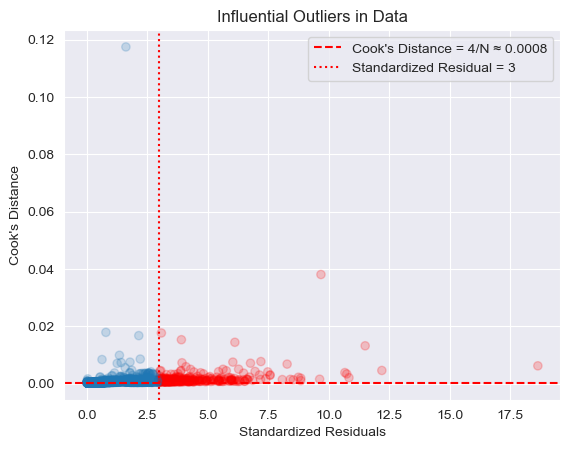

In [378]:
# Plot influence measures (Standardized Residuals) vs Cook's distance
fig, ax = plt.subplots()
colors = diagnosis_df.apply(lambda row: 'red' if row['std_resid'] > 3 and row['cooks_d'] > cook_threshold else '#1f77b4', axis=1)
ax.scatter(diagnosis_df['std_resid'], diagnosis_df['cooks_d'], alpha=0.2, c=colors)



ax.set_xlabel('Standardized Residuals')
ax.set_ylabel("Cook's Distance")
ax.set_title("Influential Outliers in Data")
axhline = ax.axhline(y=cook_threshold, ls="--", color='red')
axvline = ax.axvline(x=3, ls=":", color='red')

plt.legend([axhline, axvline], ['Cook\'s Distance = 4/N ≈ 0.0008', 'Standardized Residual = 3'], loc='upper right')
# plt.savefig('outliers_2.png', transparent=True)
plt.show()

In [379]:
# How many influential outliers are there?
influential_outliers = diagnosis_df[(diagnosis_df['cooks_d'] > cook_threshold) & (diagnosis_df['std_resid'] > 3)]
print(f"Number of influential outliers: {len(influential_outliers)}")

prop_outliers = round(100*(len(influential_outliers) / len(listings_df)),1)
print(f"Percentage of influential outliers: {prop_outliers}%")

Number of influential outliers: 276
Percentage of influential outliers: 2.8%


In [380]:
# Remove highly influential outliers from the dataset
listings_df = listings_df.drop(index=influential_outliers.index)

# NOW RUN MODEL WOO!

In [381]:
# Define the independent and dependent variables
X = listings_df.drop('legal_listing', axis=1)
y = listings_df['legal_listing']

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [382]:
logit_model = sm.Logit(y_train, X_train)
result = logit_model.fit(method='bfgs', maxiter=1000)

Optimization terminated successfully.
         Current function value: 0.146146
         Iterations: 421
         Function evaluations: 430
         Gradient evaluations: 426


In [383]:
# Test its prediction accuracy
predictions = result.predict(X_test)
predictions = (predictions > 0.5).astype(int)
accuracy = (predictions == y_test).mean()
print(f'Accuracy of the model: {accuracy:.4f}')

Accuracy of the model: 0.9421
